<a href="https://colab.research.google.com/github/isaactychique/data_science_project/blob/main/Projet_Apppartement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Projet sur la detection des prix des Appartements au Maroc  


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


### **Importation des données**

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
data = pd.read_csv('appartements_data.csv')

appartements_data = pd.DataFrame(data)
appartements_data.head()

,title,price,city_name,salon,nb_rooms,nb_baths,surface_area,equipment,link
0,CMN-MA-1752 - Appartement à vendre à Palmier,2 000 000 DH,Casablanca,NaN,2.0,2.0,168.0,Ascenseur/Balcon/Parking/Terrasse,https://www.avito.ma/fr/palmier/appartements/C...
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,1 195 000 DH,Casablanca,NaN,2.0,2.0,98.0,Ascenseur/Balcon/Chauffage/Climatisation/Cuisi...,https://www.avito.ma/fr/hay_hassani/appartemen...
2,Appartement à vendre 81 m² à Dar Bouazza,1 350 000 DH,Dar Bouazza,1.0,2.0,2.0,81.0,Ascenseur/Balcon/Chauffage/Climatisation/Conci...,https://www.avito.ma/fr/dar_bouazza/appartemen...
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,900 000 DH,Casablanca,NaN,1.0,1.0,56.0,Ascenseur/Chauffage/Climatisation/Cuisine Équi...,https://www.avito.ma/fr/centre_ville/apparteme...
4,Appartement à Rabat Agdal,3 100 000 DH,Rabat,2.0,3.0,2.0,200.0,Ascenseur/Balcon/Concierge/Parking/Sécurité,https://www.avito.ma/fr/agdal/appartements/App...


### Nettoyage et Transformation des données

#### Conversion du prix des maisons du object au float



In [ ]:
print("Avant de commencer toute analyse, je vais d'abord transformer les données du prix de \n"
"chaines de caractères en valeurs numériques\n "
"Je fais ca parce que c'est la varibale prix que l'on veut prédire\n "
"et ca sera très intéressant pour nous de voir comment il évolue aussi \n")

# Enlever les caractères non-numériques et convertir les données en float
'''
le principe c'est de convertir toutes les données en string cela nous permet d'avoir une uniformité \n ,
après quoi, on retire tout ce qui n'est pas entier (espaces, lettres et autres) et on met les points comme
des décimales\n.

Après quoi, on transforme nos données string qui contient uniquement des entiers en valeurs numériques \n
Et si on tombe sur une case vide ou une chaine vide, on remplace par null(NA)
'''
appartements_data['price'] = appartements_data['price'].astype(str).str.replace(r'[^\d.]', '', regex=True)
appartements_data['price'] = pd.to_numeric(appartements_data['price'], errors='coerce')

# Afficher pour voir que les données ont bien changé
print("\n Le Type de données du prix après la conversion:")
print(appartements_data['price'].dtype)


Avant de commencer toute analyse, je vais d'abord transformer les données du prix de 
chaines de caractères en valeurs numériques
 Je fais ca parce que c'est la varibale prix que l'on veut prédire
 et ca sera très intéressant pour nous de voir comment il évolue aussi 


 Le Type de données du prix après la conversion:
float64


####  Extraction des équipements (equipment) en variables booléennes

In [ ]:
# Prendre juste les equipements uniques dans les données de la feature
all_equipments = appartements_data['equipment'].str.split('/').explode().unique()

# Creer une nouvelle colonne pour chaque equipement et l'ajouter à notre dataset
for equipment in all_equipments:
    equipment_str = str(equipment)
    if equipment_str: # gérer les cases vides par 'false' pour juste marquer l'absence de valeurs
        appartements_data[equipment_str.strip()] = appartements_data['equipment'].str.contains(equipment_str, na=False)

# supprime la feature equiment et le nan de notre dataset
appartements_data.drop('equipment', axis=1, inplace=True)
appartements_data.drop('nan' , axis =1 , inplace= True)
# Afficher pour voir la transformation de notre dataset
appartements_data.head()

,title,price,city_name,salon,nb_rooms,nb_baths,surface_area,link,Ascenseur,Balcon,Parking,Terrasse,Chauffage,Climatisation,Cuisine Équipée,Concierge,Duplex,Sécurité,Meublé
0,CMN-MA-1752 - Appartement à vendre à Palmier,2000000.0,Casablanca,NaN,2.0,2.0,168.0,https://www.avito.ma/fr/palmier/appartements/C...,True,True,True,True,False,False,False,False,False,False,False
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,1195000.0,Casablanca,NaN,2.0,2.0,98.0,https://www.avito.ma/fr/hay_hassani/appartemen...,True,True,True,False,True,True,True,False,False,False,False
2,Appartement à vendre 81 m² à Dar Bouazza,1350000.0,Dar Bouazza,1.0,2.0,2.0,81.0,https://www.avito.ma/fr/dar_bouazza/appartemen...,True,True,True,True,True,True,True,True,True,True,False
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,900000.0,Casablanca,NaN,1.0,1.0,56.0,https://www.avito.ma/fr/centre_ville/apparteme...,True,False,True,True,True,True,True,False,False,True,True
4,Appartement à Rabat Agdal,3100000.0,Rabat,2.0,3.0,2.0,200.0,https://www.avito.ma/fr/agdal/appartements/App...,True,True,True,False,False,False,False,True,False,True,False


 #### Uniformisation des noms de villes (arabe → français)

In [ ]:
'''nous allons d'abord lister toutes les villes de notre dataset et trouver les correspondances
dans la langue francaise
'''
print(appartements_data['city_name'].unique())



['Casablanca' 'Dar Bouazza' 'Rabat' 'Marrakech' 'Asilah' 'Bouskoura'
 'Kénitra' 'Mohammedia' 'Agadir' 'Tamesna' 'Salé' 'Had Soualem' 'Temara'
 'Benslimane' 'Tanger' 'Bouznika' 'Meknès' 'Fès' 'El Jadida'
 'El Mansouria' 'Martil' 'الدار البيضاء' 'Fnideq' 'Tétouan' 'Saidia'
 'Nouaceur' 'القنيطرة' 'Tamaris' 'طنجة' 'Cabo Negro'
 'Sidi Allal El Bahraoui' 'Béni Mellal' 'أكادير' nan 'Essaouira' 'Mehdia'
 'المحمدية' 'Oujda' 'Oued Laou' 'Dcheira' 'Sidi Rahal' 'Deroua' 'مراكش'
 'Ain Attig' 'Safi' 'الرباط' 'Inzegan' 'Ifrane' 'Dakhla'
 'Dcheïra El Jihadia' 'Taghazout' 'Sidi Bouknadel' 'Skhirat' 'Khouribga'
 'Berkane' 'Mers El Kheir' 'Berrechid' 'Tiznit' 'Agadir Melloul' 'Nador'
 'El Menzeh' 'Bni Ansar' 'Mdiq' 'Tit Mellil' 'Souk El Arbaa' 'Biougra'
 'Settat' 'Ain Aouda' 'Taza' 'Khemisset' 'Oued Zem' 'Sefrou' 'Merzouga'
 'El Hajeb' 'Selouane' 'Taounate' 'Sidi Bennour' 'El Ksiba']


In [ ]:

# Faire un mapping au niveau des noms
city_mapping = {
    'الدار البيضاء': 'Casablanca',
    'الرباط': 'Rabat',
    'مراكش': 'Marrakech',
    'أكادير': 'Agadir',
    'القنيطرة' : 'Kénitra',
    'طنجة' : 'Tanger',
    'المحمدية' : 'Mohammedia'
}

# On applique  the mapping à la colonne 'city_name'
appartements_data['city_name'] = appartements_data['city_name'].replace(city_mapping)

# on voie le changement à la fin
print("Unique city names after unification:")
print(appartements_data['city_name'].unique())

Unique city names after unification:
['Casablanca' 'Dar Bouazza' 'Rabat' 'Marrakech' 'Asilah' 'Bouskoura'
 'Kénitra' 'Mohammedia' 'Agadir' 'Tamesna' 'Salé' 'Had Soualem' 'Temara'
 'Benslimane' 'Tanger' 'Bouznika' 'Meknès' 'Fès' 'El Jadida'
 'El Mansouria' 'Martil' 'Fnideq' 'Tétouan' 'Saidia' 'Nouaceur' 'Tamaris'
 'Cabo Negro' 'Sidi Allal El Bahraoui' 'Béni Mellal' nan 'Essaouira'
 'Mehdia' 'Oujda' 'Oued Laou' 'Dcheira' 'Sidi Rahal' 'Deroua' 'Ain Attig'
 'Safi' 'Inzegan' 'Ifrane' 'Dakhla' 'Dcheïra El Jihadia' 'Taghazout'
 'Sidi Bouknadel' 'Skhirat' 'Khouribga' 'Berkane' 'Mers El Kheir'
 'Berrechid' 'Tiznit' 'Agadir Melloul' 'Nador' 'El Menzeh' 'Bni Ansar'
 'Mdiq' 'Tit Mellil' 'Souk El Arbaa' 'Biougra' 'Settat' 'Ain Aouda' 'Taza'
 'Khemisset' 'Oued Zem' 'Sefrou' 'Merzouga' 'El Hajeb' 'Selouane'
 'Taounate' 'Sidi Bennour' 'El Ksiba']


In [ ]:
### Avoir des informations sur le données du Dataset
# nous voyons bien que le type du prix a été bien ajusté nous pouvons bien l'utiliser
# dans notre analyse exploratoire

appartements_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1773 entries, 0 to 1772
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            1772 non-null   object 
 1   price            1490 non-null   float64
 2   city_name        1772 non-null   object 
 3   salon            1620 non-null   float64
 4   nb_rooms         1490 non-null   float64
 5   nb_baths         1480 non-null   float64
 6   surface_area     1742 non-null   float64
 7   link             1773 non-null   object 
 8   Ascenseur        1773 non-null   bool   
 9   Balcon           1773 non-null   bool   
 10  Parking          1773 non-null   bool   
 11  Terrasse         1773 non-null   bool   
 12  Chauffage        1773 non-null   bool   
 13  Climatisation    1773 non-null   bool   
 14  Cuisine Équipée  1773 non-null   bool   
 15  Concierge        1773 non-null   bool   
 16  Duplex           1773 non-null   bool   
 17  Sécurité      

In [ ]:
# Oberser les données statistiques
appartements_data.describe()

,price,salon,nb_rooms,nb_baths,surface_area
count,1.490000e+03,1620.000000,1490.000000,1480.000000,1742.000000
mean,1.175197e+06,1.267284,2.379195,2.307432,174.933410
std,1.267979e+06,0.557539,0.667159,7.629128,2969.500693
min,3.500000e+01,0.000000,1.000000,0.000000,1.000000
25%,5.900000e+05,1.000000,2.000000,1.000000,71.000000
50%,8.800000e+05,1.000000,2.000000,2.000000,89.000000
75%,1.400000e+06,1.000000,3.000000,2.000000,114.750000
max,2.400000e+07,8.000000,7.000000,134.000000,123456.000000


## **Analyse Exploratoire des données**

#### Analyse univarié

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'salon'}>],
       [<Axes: title={'center': 'nb_rooms'}>,
        <Axes: title={'center': 'nb_baths'}>],
       [<Axes: title={'center': 'surface_area'}>, <Axes: >]], dtype=object)

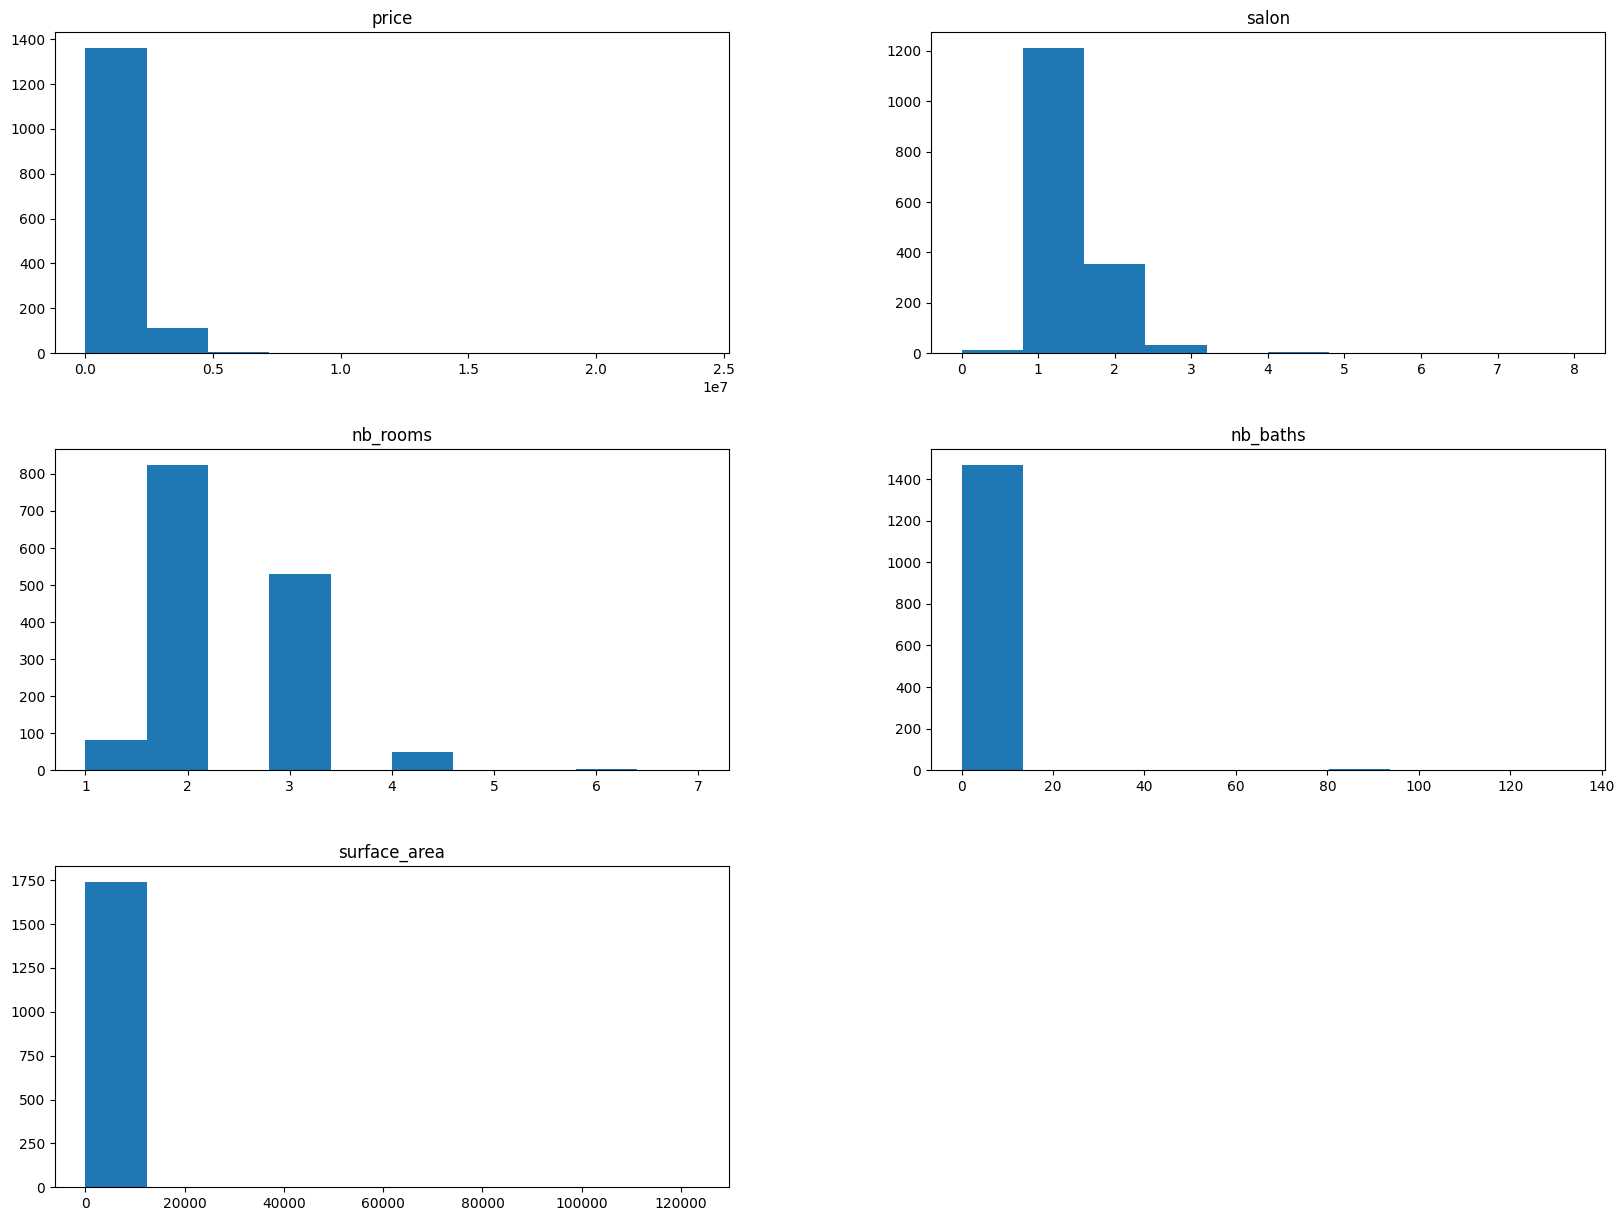

In [ ]:
appartements_data.hist(figsize=(20,15),  grid = False )

"Nous pouvons voir qu'il ya des valeurs aberrantes au niveau des prix,\nles valeurs sont trop dispersés. Les écarts entre les données est trop élevés.\nDonc il est assez complexe de voir directement si les autres features ont des valeurs aberrantes ou non.\n "

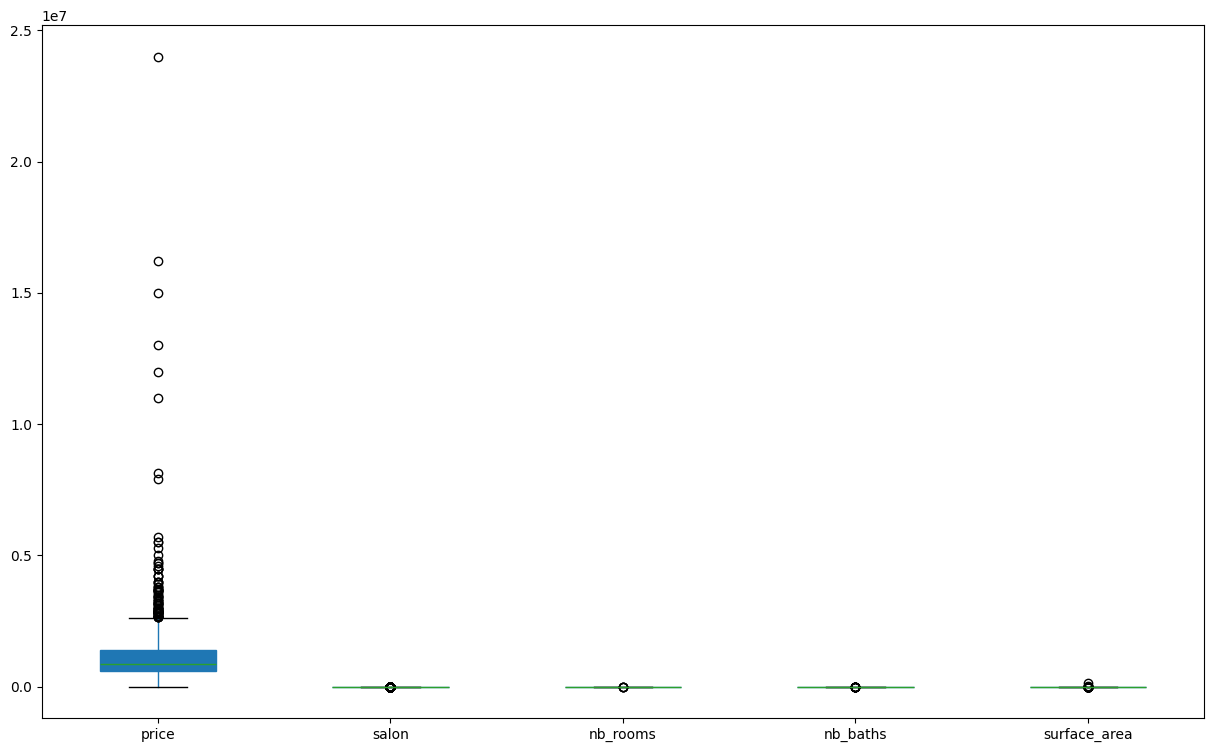

In [ ]:
# Retirer 'nan' de all_equipments avant de supprimer
all_equipments_filtered = [eq for eq in all_equipments if pd.notna(eq)]

appartements_data.drop(columns=all_equipments_filtered).boxplot( figsize = (15, 9),grid=False, patch_artist=True,
                    flierprops=dict(marker='o', markersize=6))

'''Nous pouvons voir qu'il ya des valeurs aberrantes au niveau des prix,
les valeurs sont trop dispersés. Les écarts entre les données est trop élevés.
Donc il est assez complexe de voir directement si les autres features ont des valeurs aberrantes ou non.
 '''

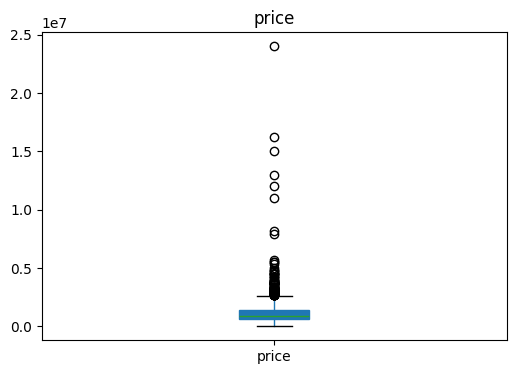

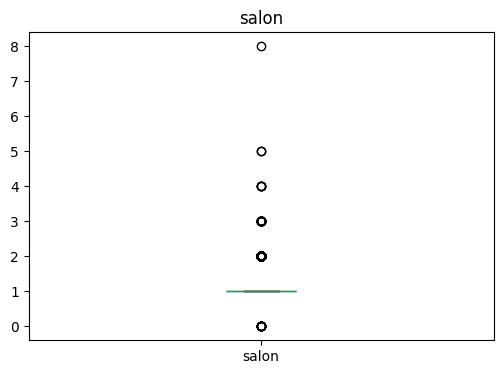

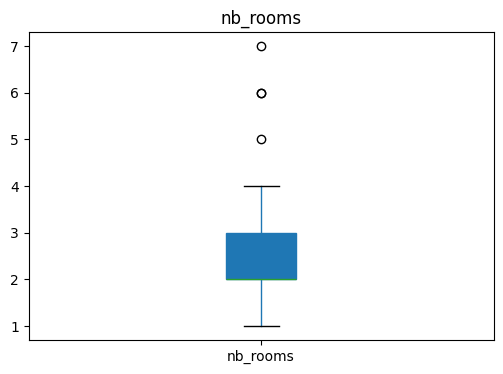

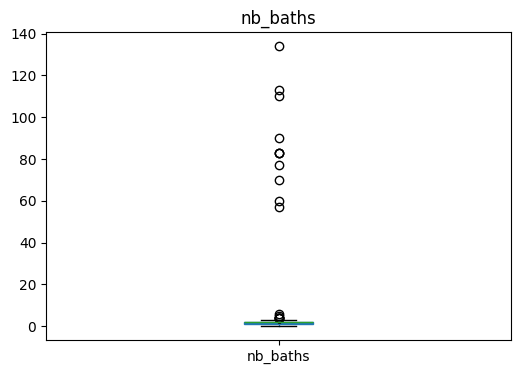

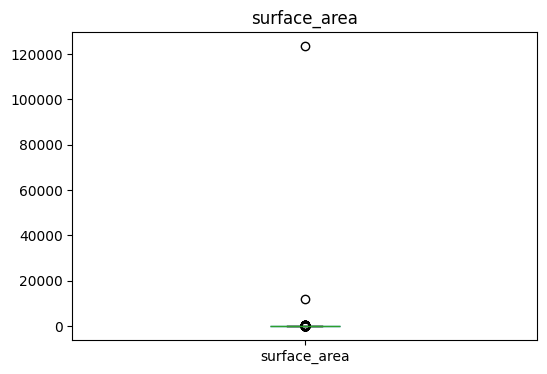

In [ ]:
# une approche qui nous permet de visualiser les boxplots de façon individuelle et voir s'ils ont des outliers
for col in appartements_data.select_dtypes(include = np.number).columns:
    appartements_data.boxplot(column=col, figsize=(6,4), grid=False, patch_artist=True,
                   flierprops=dict(marker='o', markersize=6))
    plt.title(col)
    plt.show()


" En mettant reduisons l'écart, on observe des boxplots plus visibles et plus explicatifs"

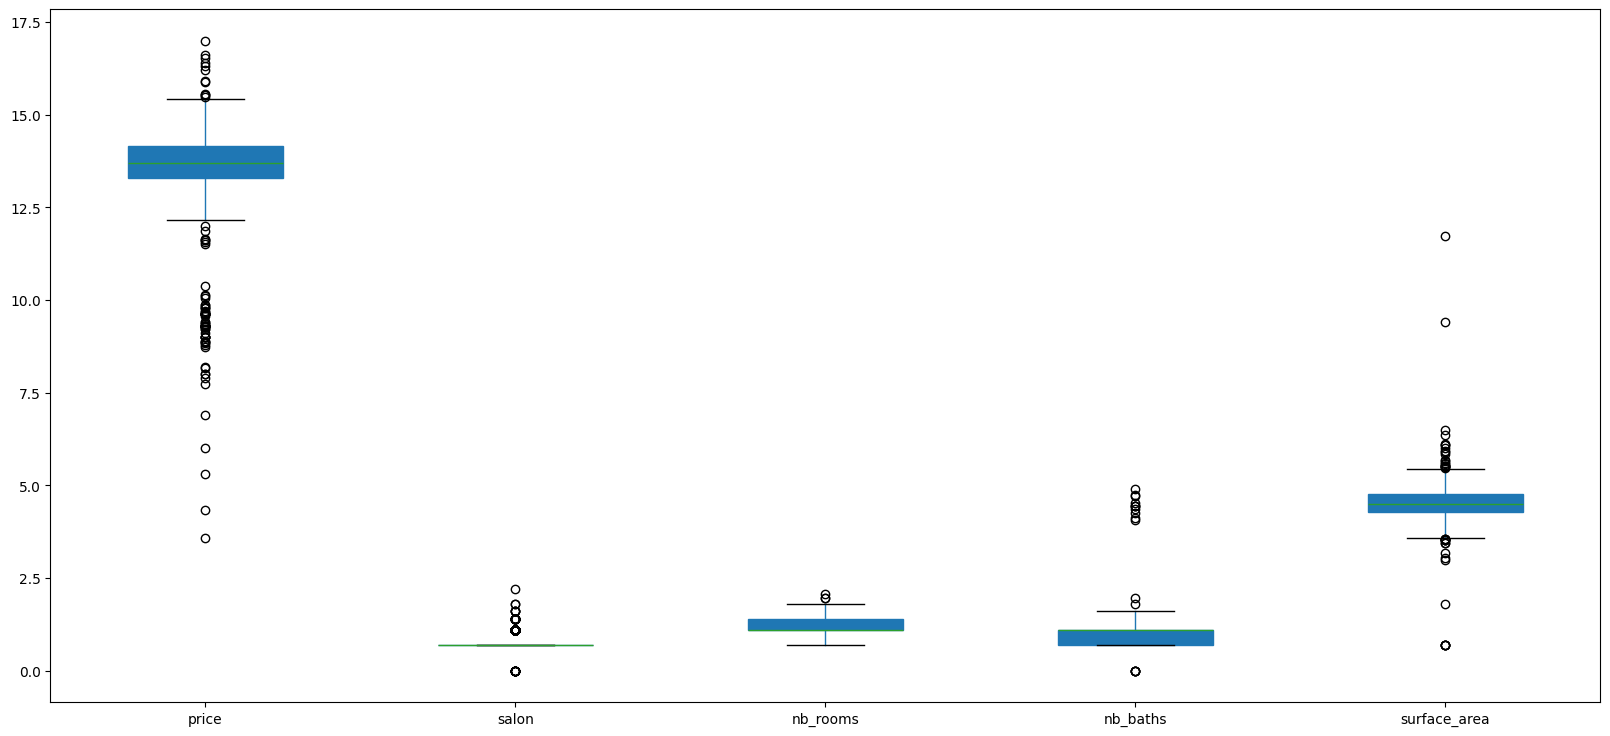

In [ ]:
df_num = appartements_data.select_dtypes(include=np.number)

# Appliquer log(1+x) pour réduire l’écart
df_log = np.log1p(df_num)

df_log.boxplot(
    figsize=(20,9),
    grid=False,
    patch_artist=True,
    flierprops=dict(marker='o', markersize=6)
)

''' En mettant reduisons l'écart, on observe des boxplots plus visibles et plus explicatifs'''

#### Analyse bivariée

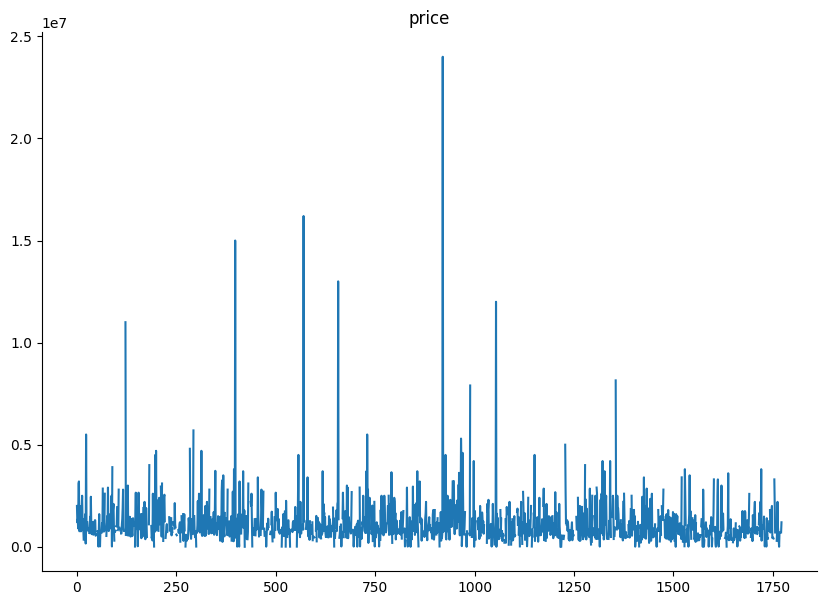

In [ ]:
## la variation des prix
from matplotlib import pyplot as plt
appartements_data['price'].plot(kind='line', figsize=(10, 7), title='price')
plt.gca().spines[['top', 'right']].set_visible(False)

" La visualisation nous montre que la plupart des features n'ont \npas de relation entre elles. Il y'a une certaine indépendance entre les features "

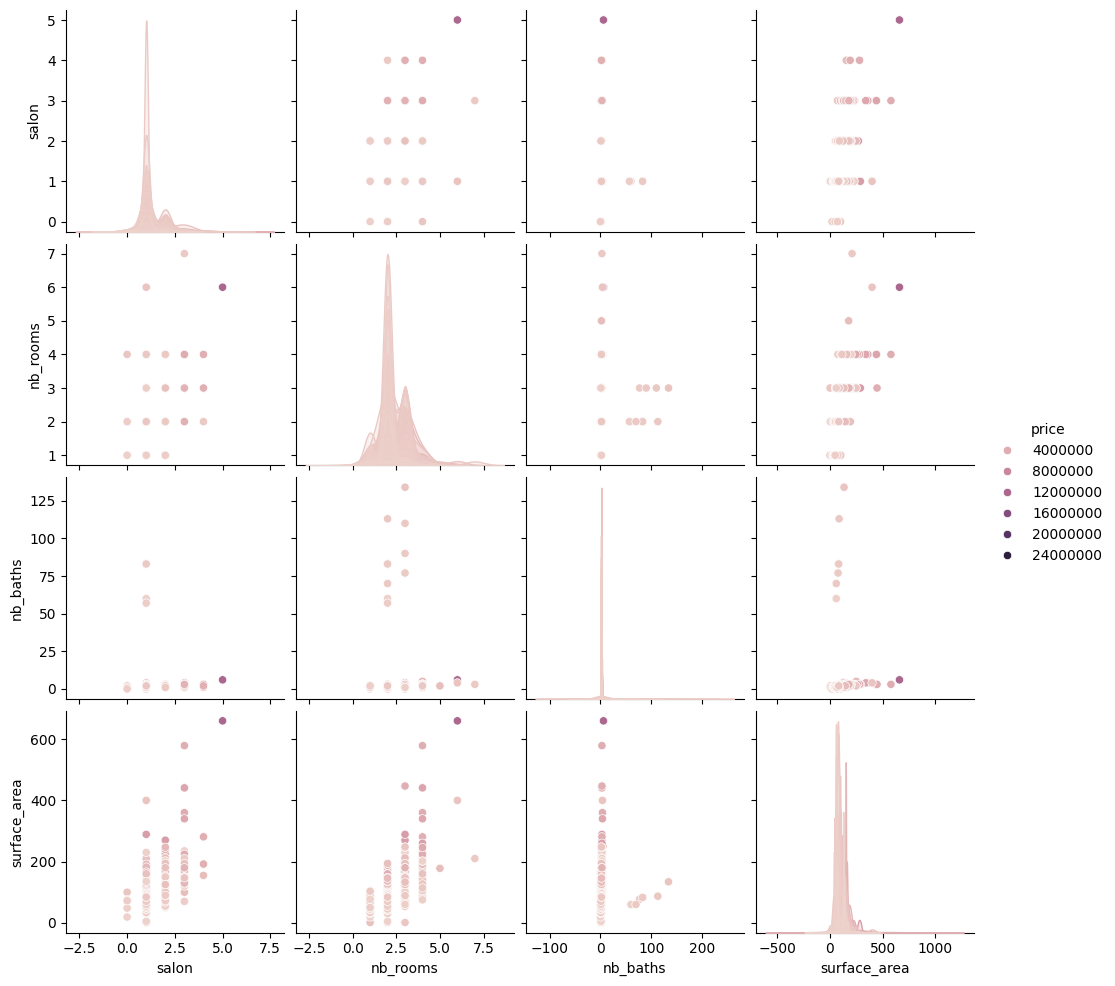

In [ ]:
sns.pairplot(appartements_data.drop(columns=all_equipments_filtered) , hue = 'price')
''' La visualisation nous montre que la plupart des features n'ont
pas de relation entre elles. Il y'a une certaine indépendance entre les features '''

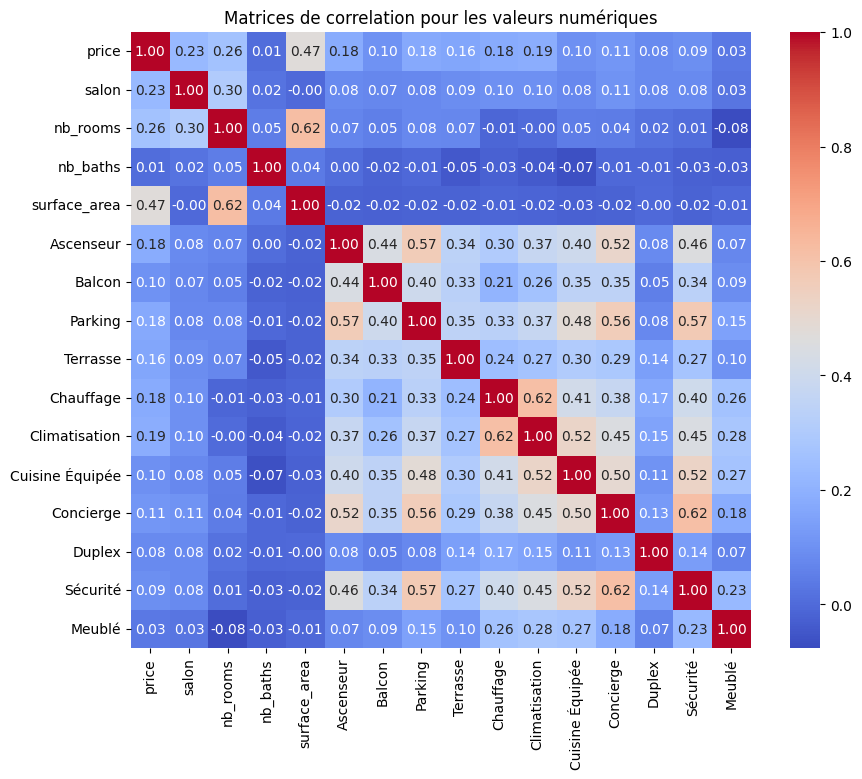

Features fortement corrélées avec le prix (>0.15) :
['salon', 'nb_rooms', 'surface_area', 'Ascenseur', 'Parking', 'Terrasse', 'Chauffage', 'Climatisation']

Features finales non redondantes :
['salon', 'nb_rooms', 'surface_area', 'Ascenseur', 'Parking', 'Terrasse', 'Chauffage', 'Climatisation']


In [ ]:

correlation_matrix = appartements_data.select_dtypes(include=["number", "bool"]).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrices de correlation pour les valeurs numériques')
plt.show()
'''La matrice de correlation nous montre que la plupart des features n'ont pas une bonne
corrélation entre eux.
La corrélation est bonne entre le nombre de chambres et la surface des maisons
La prix et la surface des maisons sont  peu corrélés

Dans le cahier de charges, nous considerons des features significatifs pour la prédiction du prix des maisons
Et nous selections ceux qui ont une corrélation  > 0.15 avec le prix des maisons et non redondantes
'''

#selectionner les features qui sont corrélés avec notre prix de prédictions

threshold = 0.15
# On exclut 'price' lui-même et on ne garde que les corrélations > threshold
high_corr_features = correlation_matrix['price'][correlation_matrix['price'].abs() > threshold].index.tolist()

# Optionnel : retirer 'price' de la liste
high_corr_features = [feat for feat in high_corr_features if feat != 'price']

print("Features fortement corrélées avec le prix (>0.15) :")
print(high_corr_features)


# Créer un sous-matrix de corrélation entre les features sélectionnées
subset_corr = correlation_matrix.loc[high_corr_features, high_corr_features].abs()

# Liste finale des features non redondantes
selected_features = []

for col in subset_corr.columns:
    # Vérifier si cette colonne est déjà fortement corrélée avec une feature déjà sélectionnée
    if not any(subset_corr[col][selected_features] > 0.8):
        selected_features.append(col)

print("\nFeatures finales non redondantes :")
print(selected_features)

In [ ]:
## recolter les variables qui sont non corrélés avec le prix
non_selected_features = [feat for feat in appartements_data.columns if feat not in selected_features]
print(non_selected_features)

['title', 'price', 'city_name', 'nb_baths', 'link', 'Balcon', 'Cuisine Équipée', 'Concierge', 'Duplex', 'Sécurité', 'Meublé']


## Gestion des outliers et des valeurs manquantes

### Valeurs manquantes

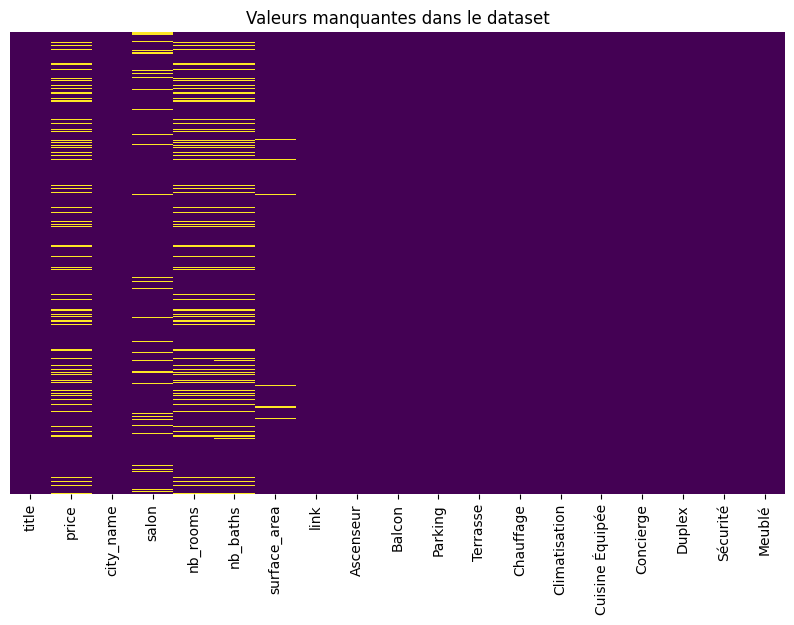

In [ ]:
# Créer la heatmap pour détecter les valeurs manquantes pour nos features
plt.figure(figsize=(10,6))
sns.heatmap(appartements_data.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Valeurs manquantes dans le dataset")
plt.show()

In [ ]:
appartements_data.isnull().sum()

,0
title,1
price,283
city_name,1
salon,153
nb_rooms,283
nb_baths,293
surface_area,31
link,0
Ascenseur,0
Balcon,0


In [ ]:
'''
Nous pouvons voir qu'au niveau de nos features, nous avons des valeurs nulles,
nous allons les gérer en les remplaçant par la mediane pour les variables numériques.
Pour les données catégorielles comme 'title' et 'city_name' qui ont très peu de valeurs manquantes,
nous pouvons les gérer séparément si nécessaire (par exemple, en les remplacant par le mode ou une valeur "Inconnu").
'''
# Select only numerical columns
numerical_cols = appartements_data.select_dtypes(include=np.number).columns

# Fill missing values in numerical columns with the median of each column
appartements_data[numerical_cols] = appartements_data[numerical_cols].fillna(appartements_data[numerical_cols].median())

# You might want to handle missing values in non-numerical columns separately if needed.
# For example, for 'title' and 'city_name', which have only one missing value each:
appartements_data['title'].fillna('Inconnu', inplace=True)
appartements_data['city_name'].fillna('Inconnu', inplace=True)


print("\nNombre de valeurs manquantes après imputation:")
print(appartements_data.isnull().sum())


Nombre de valeurs manquantes après imputation:
title              0
price              0
city_name          0
salon              0
nb_rooms           0
nb_baths           0
surface_area       0
link               0
Ascenseur          0
Balcon             0
Parking            0
Terrasse           0
Chauffage          0
Climatisation      0
Cuisine Équipée    0
Concierge          0
Duplex             0
Sécurité           0
Meublé             0
dtype: int64


/tmp/ipython-input-1410979624.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  appartements_data['title'].fillna('Inconnu', inplace=True)
/tmp/ipython-input-1410979624.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

### Gestion des outliers


 Nombres de lignes avant la suppression des outliers : 1773
Feature 'price' : 146 outliers détectés


/tmp/ipython-input-2034620294.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([appartements_data[feature], df_cleaned[feature]], labels=['Avant', 'Après'])


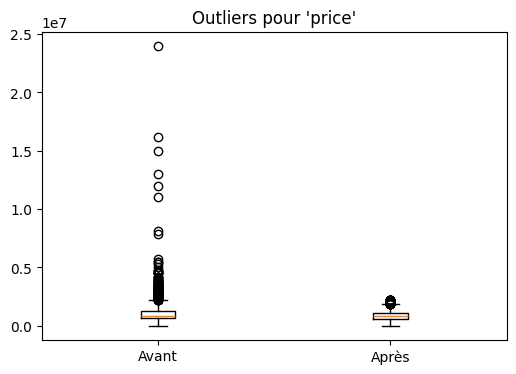

/tmp/ipython-input-2034620294.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([appartements_data[feature], df_cleaned[feature]], labels=['Avant', 'Après'])


Feature 'salon' : 347 outliers détectés


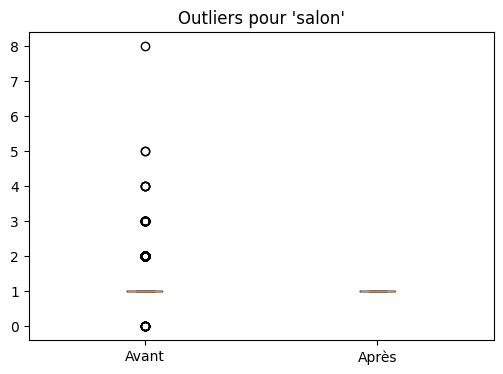

Feature 'nb_rooms' : 2 outliers détectés


/tmp/ipython-input-2034620294.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([appartements_data[feature], df_cleaned[feature]], labels=['Avant', 'Après'])


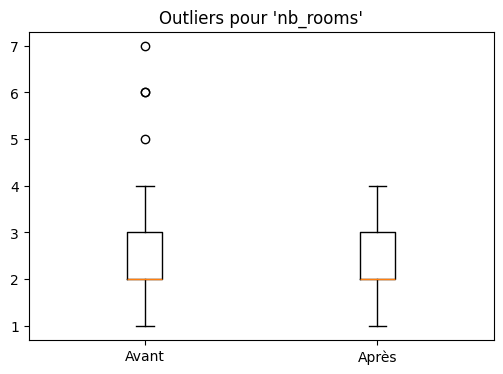

Feature 'nb_baths' : 11 outliers détectés


/tmp/ipython-input-2034620294.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([appartements_data[feature], df_cleaned[feature]], labels=['Avant', 'Après'])


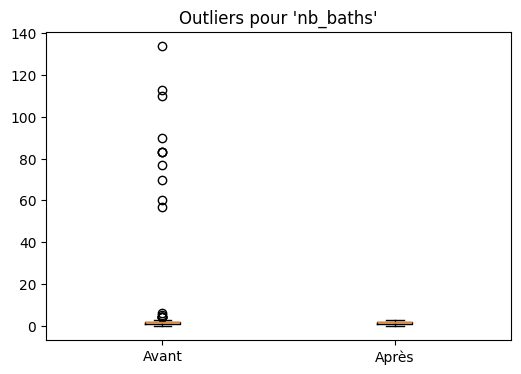

Feature 'surface_area' : 28 outliers détectés


/tmp/ipython-input-2034620294.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([appartements_data[feature], df_cleaned[feature]], labels=['Avant', 'Après'])


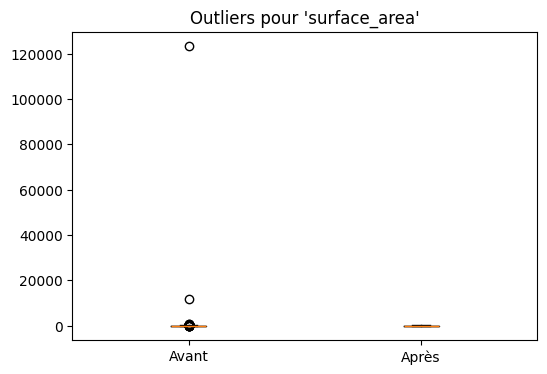


Dataset nettoyé : 1239 lignes restantes après suppression des outliers


In [ ]:
''' En observant les boxplots, nous avons detecté les valeurs abérrantes juste au niveau
de la variable cible et nous allons gérer ces outliers
Pour les prix d’appartements (distribution souvent asymétrique et avec des valeurs extrêmes)
IQR est plus approprié et plus robuste que le Z-score(distrubition symétrique).
'''
print(f"\n Nombres de lignes avant la suppression des outliers : {appartements_data.shape[0]}")
#on garde juuste nos features qui sont tous numériques ici
numerical_features = appartements_data.select_dtypes(include=np.number).columns

# Copier le dataset pour nettoyage
df_cleaned = appartements_data.copy()

for feature in numerical_features:
    # Calculer Q1, Q3 et IQR
    Q1 = df_cleaned[feature].quantile(0.25)
    Q3 = df_cleaned[feature].quantile(0.75)
    IQR = Q3 - Q1

    # Définir les limites
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Compter les outliers avant suppression
    outliers_count = df_cleaned[(df_cleaned[feature] < lower_bound) | (df_cleaned[feature] > upper_bound)].shape[0]
    print(f"Feature '{feature}' : {outliers_count} outliers détectés")

    #suppression des outliers détectés
    df_cleaned = df_cleaned[(df_cleaned[feature] >= lower_bound) & (df_cleaned[feature] <= upper_bound)]

     # Boxplot avant/après
    plt.figure(figsize=(6,4))
    plt.boxplot([appartements_data[feature], df_cleaned[feature]], labels=['Avant', 'Après'])
    plt.title(f"Outliers pour '{feature}'")
    plt.show()

print(f"\nDataset nettoyé : {df_cleaned.shape[0]} lignes restantes après suppression des outliers")



## Encodage des valeurs catégorielles et des booleens.

Pour que notre modèle puisse bien interpréter les valeurs que nous allons lui donner, nous allons encoder les variables catégorielles et les booléens

In [ ]:
# Encodage des booléens
bool_columns = appartements_data.select_dtypes(include='bool').columns.tolist()
df_cleaned[bool_columns] = df_cleaned[bool_columns].astype(int)

df_cleaned.head()

,title,price,city_name,salon,nb_rooms,nb_baths,surface_area,link,Ascenseur,Balcon,Parking,Terrasse,Chauffage,Climatisation,Cuisine Équipée,Concierge,Duplex,Sécurité,Meublé
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,1195000.0,Casablanca,1.0,2.0,2.0,98.0,https://www.avito.ma/fr/hay_hassani/appartemen...,1,1,1,0,1,1,1,0,0,0,0
2,Appartement à vendre 81 m² à Dar Bouazza,1350000.0,Dar Bouazza,1.0,2.0,2.0,81.0,https://www.avito.ma/fr/dar_bouazza/appartemen...,1,1,1,1,1,1,1,1,1,1,0
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,900000.0,Casablanca,1.0,1.0,1.0,56.0,https://www.avito.ma/fr/centre_ville/apparteme...,1,0,1,1,1,1,1,0,0,1,1
6,Appartement à vendre 98 m² à Marrakech,760000.0,Marrakech,1.0,3.0,3.0,98.0,https://www.avito.ma/fr/akioud/appartements/Ap...,1,1,1,0,0,0,1,1,0,1,0
7,50620-Vente Appt à Casablanca Hay Mohammadi de 73,790000.0,Casablanca,1.0,3.0,2.0,73.0,https://www.avito.ma/fr/hay_mohammadi/appartem...,0,0,0,0,0,0,1,0,0,0,0


#### LabelEncoder pour un certain modèle de ML

In [ ]:
from sklearn.preprocessing import LabelEncoder
'''
Pour arbres de décision, random forest, gradient boosting,
nous allons faire le label encoding.
'''
data_label_encoding = df_cleaned.copy()
# Encoder les variables catégorielles
le = LabelEncoder()
# Appliquer l'encodage
data_label_encoding['city_name'] = le.fit_transform(data_label_encoding['city_name'])
data_label_encoding.head()

,title,price,city_name,salon,nb_rooms,nb_baths,surface_area,link,Ascenseur,Balcon,Parking,Terrasse,Chauffage,Climatisation,Cuisine Équipée,Concierge,Duplex,Sécurité,Meublé
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,1195000.0,11,1.0,2.0,2.0,98.0,https://www.avito.ma/fr/hay_hassani/appartemen...,1,1,1,0,1,1,1,0,0,0,0
2,Appartement à vendre 81 m² à Dar Bouazza,1350000.0,13,1.0,2.0,2.0,81.0,https://www.avito.ma/fr/dar_bouazza/appartemen...,1,1,1,1,1,1,1,1,1,1,0
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,900000.0,11,1.0,1.0,1.0,56.0,https://www.avito.ma/fr/centre_ville/apparteme...,1,0,1,1,1,1,1,0,0,1,1
6,Appartement à vendre 98 m² à Marrakech,760000.0,30,1.0,3.0,3.0,98.0,https://www.avito.ma/fr/akioud/appartements/Ap...,1,1,1,0,0,0,1,1,0,1,0
7,50620-Vente Appt à Casablanca Hay Mohammadi de 73,790000.0,11,1.0,3.0,2.0,73.0,https://www.avito.ma/fr/hay_mohammadi/appartem...,0,0,0,0,0,0,1,0,0,0,0


#### One-Hot-Encoding pour un certain nombre de modèles de ML
  

In [ ]:
#One-hot encoding des villes
'''
Procédure adéquate pour les modèles de régressions linéaires, SVM, KNN
'''

# standardiser majuscules/minuscules
data_onehot_encoding = df_cleaned.copy()
data_onehot_encoding['city_name'] = data_onehot_encoding['city_name'].str.title()

data_onehot_encoding= pd.get_dummies(data_onehot_encoding, columns=['city_name'])
data_onehot_encoding.head()

,title,price,salon,nb_rooms,nb_baths,surface_area,link,Ascenseur,Balcon,Parking,...,city_name_Skhirat,city_name_Tamaris,city_name_Tamesna,city_name_Tanger,city_name_Taounate,city_name_Taza,city_name_Temara,city_name_Tit Mellil,city_name_Tiznit,city_name_Tétouan
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,1195000.0,1.0,2.0,2.0,98.0,https://www.avito.ma/fr/hay_hassani/appartemen...,1,1,1,...,False,False,False,False,False,False,False,False,False,False
2,Appartement à vendre 81 m² à Dar Bouazza,1350000.0,1.0,2.0,2.0,81.0,https://www.avito.ma/fr/dar_bouazza/appartemen...,1,1,1,...,False,False,False,False,False,False,False,False,False,False
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,900000.0,1.0,1.0,1.0,56.0,https://www.avito.ma/fr/centre_ville/apparteme...,1,0,1,...,False,False,False,False,False,False,False,False,False,False
6,Appartement à vendre 98 m² à Marrakech,760000.0,1.0,3.0,3.0,98.0,https://www.avito.ma/fr/akioud/appartements/Ap...,1,1,1,...,False,False,False,False,False,False,False,False,False,False
7,50620-Vente Appt à Casablanca Hay Mohammadi de 73,790000.0,1.0,3.0,2.0,73.0,https://www.avito.ma/fr/hay_mohammadi/appartem...,0,0,0,...,False,False,False,False,False,False,False,False,False,False


### Mise à échelle de mes valeurs numériques

In [ ]:
from sklearn.preprocessing import StandardScaler

se = StandardScaler()
data_onehot_encoding[numerical_features] = se.fit_transform(data_onehot_encoding[numerical_features])
data_onehot_encoding.head()



,title,price,salon,nb_rooms,nb_baths,surface_area,link,Ascenseur,Balcon,Parking,...,city_name_Skhirat,city_name_Tamaris,city_name_Tamesna,city_name_Tanger,city_name_Taounate,city_name_Taza,city_name_Temara,city_name_Tit Mellil,city_name_Tiznit,city_name_Tétouan
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,0.774051,0.0,-0.367749,0.769735,0.631357,https://www.avito.ma/fr/hay_hassani/appartemen...,1,1,1,...,False,False,False,False,False,False,False,False,False,False
2,Appartement à vendre 81 m² à Dar Bouazza,1.132246,0.0,-0.367749,0.769735,-0.098956,https://www.avito.ma/fr/dar_bouazza/appartemen...,1,1,1,...,False,False,False,False,False,False,False,False,False,False
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,0.092323,0.0,-2.219947,-1.145328,-1.172947,https://www.avito.ma/fr/centre_ville/apparteme...,1,0,1,...,False,False,False,False,False,False,False,False,False,False
6,Appartement à vendre 98 m² à Marrakech,-0.231209,0.0,1.484449,2.684798,0.631357,https://www.avito.ma/fr/akioud/appartements/Ap...,1,1,1,...,False,False,False,False,False,False,False,False,False,False
7,50620-Vente Appt à Casablanca Hay Mohammadi de 73,-0.161880,0.0,1.484449,0.769735,-0.442633,https://www.avito.ma/fr/hay_mohammadi/appartem...,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
data_label_encoding[numerical_features] = se.fit_transform(data_label_encoding[numerical_features])
data_label_encoding.head()

,title,price,city_name,salon,nb_rooms,nb_baths,surface_area,link,Ascenseur,Balcon,Parking,Terrasse,Chauffage,Climatisation,Cuisine Équipée,Concierge,Duplex,Sécurité,Meublé
1,66370-Vente Appt à Casablanca Hay Hassani de 1...,0.774051,11,0.0,-0.367749,0.769735,0.631357,https://www.avito.ma/fr/hay_hassani/appartemen...,1,1,1,0,1,1,1,0,0,0,0
2,Appartement à vendre 81 m² à Dar Bouazza,1.132246,13,0.0,-0.367749,0.769735,-0.098956,https://www.avito.ma/fr/dar_bouazza/appartemen...,1,1,1,1,1,1,1,1,1,1,0
3,63860-Vente Appt à Casablanca Quartier Bd Med ...,0.092323,11,0.0,-2.219947,-1.145328,-1.172947,https://www.avito.ma/fr/centre_ville/apparteme...,1,0,1,1,1,1,1,0,0,1,1
6,Appartement à vendre 98 m² à Marrakech,-0.231209,30,0.0,1.484449,2.684798,0.631357,https://www.avito.ma/fr/akioud/appartements/Ap...,1,1,1,0,0,0,1,1,0,1,0
7,50620-Vente Appt à Casablanca Hay Mohammadi de 73,-0.161880,11,0.0,1.484449,0.769735,-0.442633,https://www.avito.ma/fr/hay_mohammadi/appartem...,0,0,0,0,0,0,1,0,0,0,0


## Selection des variables explicatives

In [ ]:
print(selected_features)
print(non_selected_features)

['salon', 'nb_rooms', 'surface_area', 'Ascenseur', 'Parking', 'Terrasse', 'Chauffage', 'Climatisation']
['title', 'price', 'city_name', 'nb_baths', 'link', 'Balcon', 'Cuisine Équipée', 'Concierge', 'Duplex', 'Sécurité', 'Meublé']


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

'''
Nous allons retirer dans notre dataset le title et link ce sont des features qui
n'ont pas de valeurs significatives pour notre prédiction du prix des maisons
'''
#data_onehot_encoding = data_onehot_encoding.drop([], axis=1)
#data_label_encoding = data_label_encoding.drop(['title', 'link'], axis=1)


'''
D'après le cahier de charges, nous allons considérer que les features \n
dont la corrélation avec notre cible est inférieure à 0.15 sont non significatives
'''


# on veut preserver les binaires des villes
non_selected_features.remove("city_name")
print(non_selected_features)
X_onehot = data_onehot_encoding.drop(non_selected_features, axis=1)
print(X_onehot.columns)

y_onehot = data_onehot_encoding['price']




### On garde que les features significatives
selected_features = selected_features + ['city_name']
print(selected_features)
X_label = data_label_encoding.drop(['price' , 'title', 'link'], axis=1)
X_label = X_label[selected_features]
y_label = data_label_encoding['price']





['title', 'price', 'nb_baths', 'link', 'Balcon', 'Cuisine Équipée', 'Concierge', 'Duplex', 'Sécurité', 'Meublé']
Index(['salon', 'nb_rooms', 'surface_area', 'Ascenseur', 'Parking', 'Terrasse',
       'Chauffage', 'Climatisation', 'city_name_Agadir',
       'city_name_Agadir Melloul', 'city_name_Ain Aouda',
       'city_name_Ain Attig', 'city_name_Asilah', 'city_name_Berrechid',
       'city_name_Biougra', 'city_name_Bouskoura', 'city_name_Bouznika',
       'city_name_Béni Mellal', 'city_name_Cabo Negro', 'city_name_Casablanca',
       'city_name_Dakhla', 'city_name_Dar Bouazza', 'city_name_Dcheira',
       'city_name_Dcheïra El Jihadia', 'city_name_Deroua',
       'city_name_El Jadida', 'city_name_El Mansouria', 'city_name_El Menzeh',
       'city_name_Essaouira', 'city_name_Fnideq', 'city_name_Fès',
       'city_name_Had Soualem', 'city_name_Ifrane', 'city_name_Inconnu',
       'city_name_Inzegan', 'city_name_Khemisset', 'city_name_Khouribga',
       'city_name_Kénitra', 'city_name_Ma

## Separation de mes données

In [ ]:
# on va separer les données en données d'entrainement et de test

X_train_onehot, X_test_onehot, y_train_onehot, y_test_onehot = train_test_split(X_onehot, y_onehot, test_size=0.2, random_state=42)
X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)


## Entrainement de nos modèles de ML
## Sur la dataset OneHotEncoding
 ### KNN
 One-hot encoding des villes
'''
Procédure adéquate pour les modèles de régressions linéaires, SVM, KNN
'''

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score , accuracy_score, classification_report
knn = KNeighborsRegressor(
    n_neighbors=6,     # nombre de voisins
    weights="distance", # pondération par distance
    metric="minkowski", # distance Minkowski
    p=2,                # p=2 -> Euclidienne, p=1 -> Manhattan
    leaf_size=30,       # paramètre pour optimiser la recherche des voisins
    n_jobs=-1           # utiliser tous les cœurs pour accélérer
)
knn.fit(X_train_onehot, y_train_onehot)

y_pred_onehot = knn.predict(X_test_onehot)


mse_onehot = mean_squared_error(y_test_onehot, y_pred_onehot)
r2_onehot = r2_score(y_test_onehot, y_pred_onehot)

print(f"Mean Squared Error (One-Hot Encoding): {mse_onehot:.2f}")
print(f"R-squared (One-Hot Encoding): {r2_onehot:.2f}\n")

valeur_comparaison = pd.DataFrame({'Valeur réelle': y_test_onehot, 'Valeur prédite': y_pred_onehot})
print(valeur_comparaison)

Mean Squared Error (One-Hot Encoding): 0.60
R-squared (One-Hot Encoding): 0.36

      Valeur réelle  Valeur prédite
613       -0.254318       -0.084938
380        0.046104       -0.266685
491       -0.508521        0.190474
928       -0.993819       -0.881689
140       -0.647178       -0.486798
...             ...             ...
741       -0.554740       -0.554740
1608      -1.525335       -0.957047
255       -0.092552       -0.200011
39         0.046104       -0.496566
1071      -0.577850        0.157058

[248 rows x 2 columns]


### SVM

In [ ]:
from sklearn.svm import SVR

svm = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svm.fit(X_train_onehot, y_train_onehot)

y_pred_onehot = svm.predict(X_test_onehot)

mse_onehot = mean_squared_error(y_test_onehot, y_pred_onehot)
r2_onehot = r2_score(y_test_onehot, y_pred_onehot)

print(f"Mean Squared Error (One-Hot Encoding): {mse_onehot:.2f}")
print(f"R-squared (One-Hot Encoding): {r2_onehot:.2f}\n")

valeur_comparaison = pd.DataFrame({'Valeur réelle': y_test_onehot, 'Valeur prédite': y_pred_onehot})
print(valeur_comparaison)


Mean Squared Error (One-Hot Encoding): 0.65
R-squared (One-Hot Encoding): 0.31

      Valeur réelle  Valeur prédite
613       -0.254318       -0.229258
380        0.046104       -0.330313
491       -0.508521        0.048461
928       -0.993819       -0.976869
140       -0.647178       -0.571086
...             ...             ...
741       -0.554740       -0.454889
1608      -1.525335       -1.134729
255       -0.092552       -0.422314
39         0.046104       -0.771895
1071      -0.577850        0.311492

[248 rows x 2 columns]


#### Regression Linéaire

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_onehot, y_train_onehot)

y_pred_onehot = lr.predict(X_test_onehot)

mae_label = mean_squared_error(y_test_onehot, y_pred_onehot)
mse_label = mean_squared_error(y_test_onehot, y_pred_onehot)
r2_label = r2_score(y_test_onehot, y_pred_onehot)

print(f"Mean Squared Error (Label Encoding): {mse_label:.2f}")
print(f"R-squared (Label Encoding): {r2_label:.2f}\n")

valeur_comparaison = pd.DataFrame({'Valeur réelle': y_test_onehot, 'Valeur prédite': y_pred_onehot})
print(valeur_comparaison)


Mean Squared Error (Label Encoding): 0.75
R-squared (Label Encoding): 0.20

      Valeur réelle  Valeur prédite
613       -0.254318       -0.614489
380        0.046104       -0.417038
491       -0.508521       -0.032946
928       -0.993819       -0.616252
140       -0.647178       -0.390600
...             ...             ...
741       -0.554740       -0.393370
1608      -1.525335       -1.501815
255       -0.092552       -0.125106
39         0.046104       -0.820387
1071      -0.577850        0.148271

[248 rows x 2 columns]


In [ ]:
from sklearn.linear_model import  Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Liste des modèles à tester
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5)
}

# DataFrame pour stocker les résultats
results = []

#Boucle sur chaque modèle
for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        (name, model)
    ])

    # Entraînement
    pipe.fit(X_train_onehot, y_train_onehot)

    # Prédictions
    y_pred = pipe.predict(X_test_onehot)

    # Métriques
    mae = mean_absolute_error(y_test_onehot, y_pred)
    mse = mean_squared_error(y_test_onehot, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_onehot, y_pred)

    results.append([name, mae, rmse, r2])

#  Résultats dans un DataFrame
results_df = pd.DataFrame(results, columns=["Modèle", "MAE", "RMSE", "R²"])
print(results_df)

              Modèle       MAE      RMSE        R²
0  Linear Regression  0.600858  0.866429  0.199469
1              Ridge  0.600779  0.866232  0.199833
2              Lasso  0.592738  0.858300  0.214419
3         ElasticNet  0.595762  0.860484  0.210416


## Sur le Dataset Label Encoding

### KNN

In [ ]:
knn = KNeighborsRegressor(
    n_neighbors=6,     # nombre de voisins
    weights="distance", # pondération par distance
    metric="minkowski", # distance Minkowski
    p=2,                # p=2 -> Euclidienne, p=1 -> Manhattan
    leaf_size=30,       # paramètre pour optimiser la recherche des voisins
    n_jobs=-1           # utiliser tous les cœurs pour accélérer
)
knn.fit(X_train_label, y_train_label)

y_pred_label = knn.predict(X_test_label)


mse_label = mean_squared_error(y_test_label, y_pred_label)
r2_label = r2_score(y_test_label, y_pred_label)

print(f"Mean Squared Error (Label Encoding): {mse_label:.2f}")
print(f"R-squared (Label Encoding): {r2_label:.2f}\n")

valeur_comparaison = pd.DataFrame({'Valeur réelle': y_test_label, 'Valeur prédite': y_pred_label})
print(valeur_comparaison)

Mean Squared Error (Label Encoding): 0.59
R-squared (Label Encoding): 0.37

      Valeur réelle  Valeur prédite
613       -0.254318       -0.084938
380        0.046104       -0.266685
491       -0.508521        0.458591
928       -0.993819       -0.231879
140       -0.647178       -0.486798
...             ...             ...
741       -0.554740       -0.554740
1608      -1.525335        0.017282
255       -0.092552       -0.200011
39         0.046104       -0.496566
1071      -0.577850        0.457677

[248 rows x 2 columns]


### SVM

In [ ]:
svm = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svm.fit(X_train_label, y_train_label)

y_pred_label = svm.predict(X_test_label)

mse_onehot = mean_squared_error(y_test_label, y_pred_label)
r2_onehot = r2_score(y_test_label, y_pred_label)

print(f"Mean Squared Error (One-Hot Encoding): {mse_label:.2f}")
print(f"R-squared (One-Hot Encoding): {r2_label:.2f}\n")

valeur_comparaison = pd.DataFrame({'Valeur réelle': y_test_label, 'Valeur prédite': y_pred_label})
print(valeur_comparaison)


Mean Squared Error (One-Hot Encoding): 0.59
R-squared (One-Hot Encoding): 0.37

      Valeur réelle  Valeur prédite
613       -0.254318       -0.405024
380        0.046104       -0.168830
491       -0.508521        0.096654
928       -0.993819       -0.469542
140       -0.647178       -0.146665
...             ...             ...
741       -0.554740        0.379137
1608      -1.525335       -0.367094
255       -0.092552       -0.100767
39         0.046104       -0.278866
1071      -0.577850        0.220187

[248 rows x 2 columns]


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rd = RandomForestRegressor(n_estimators=100, random_state=42 ,max_depth =10)
rd.fit(X_train_label, y_train_label)

y_pred_label = rd.predict(X_test_label)

mse_label = mean_squared_error(y_test_label, y_pred_label)
r2_label = r2_score(y_test_label, y_pred_label)

print(f"Mean Squared Error (Label Encoding): {mse_label:.2f}")
print(f"R-squared (Label Encoding): {r2_label:.2f}\n")

valeur_comparaison = pd.DataFrame({'Valeur réelle': y_test_label, 'Valeur prédite': y_pred_label})
print(valeur_comparaison)


Mean Squared Error (Label Encoding): 0.65
R-squared (Label Encoding): 0.31

      Valeur réelle  Valeur prédite
613       -0.254318       -0.158734
380        0.046104       -0.235806
491       -0.508521        0.481426
928       -0.993819       -0.867180
140       -0.647178       -0.210382
...             ...             ...
741       -0.554740       -0.411028
1608      -1.525335       -0.821664
255       -0.092552       -0.227226
39         0.046104       -0.617858
1071      -0.577850        0.970041

[248 rows x 2 columns]


### Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42 , max_depth=3)


gb.fit(X_train_label, y_train_label)
y_pred_label = gb.predict(X_test_label)

mse_label = mean_squared_error(y_test_label, y_pred_label)
r2_label = r2_score(y_test_label, y_pred_label)

print(f"Mean Squared Error (Label Encoding): {mse_label :.2f}")
print(f"R-squared (Label Encoding): {r2_label :.2f}\n")

valeur_comparaison = pd.DataFrame({'Valeur réelle': y_test_label, 'Valeur prédite': y_pred_label})
print(valeur_comparaison)


Mean Squared Error (Label Encoding): 0.61
R-squared (Label Encoding): 0.35

      Valeur réelle  Valeur prédite
613       -0.254318       -0.197187
380        0.046104       -0.440395
491       -0.508521        0.074494
928       -0.993819       -0.489600
140       -0.647178       -0.276833
...             ...             ...
741       -0.554740       -0.385406
1608      -1.525335       -1.147958
255       -0.092552       -0.153263
39         0.046104       -1.278118
1071      -0.577850        0.317512

[248 rows x 2 columns]


### Reseau de Neurones (MLP Regressor)

In [ ]:
! pip install tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train_label.shape[1],)))
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))


optimizer = Adam(learning_rate=0.001)
model.compile(optimizer = optimizer , loss='mean_squared_error')

# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.fit(X_train_label, y_train_label, epochs=100, validation_split=0.2,
          #callbacks=[early_stop],
          batch_size=32, verbose=1)

y_pred_label = model.predict(X_test_label)

mse_label = mean_squared_error(y_test_label, y_pred_label)
r2_label = r2_score(y_test_label, y_pred_label)

print(f"Mean Squared Error (Label Encoding): {mse_label:.2f}")
print(f"R-squared (Label Encoding): {r2_label:.2f}\n")

valeur_comparaison = pd.DataFrame({'Valeur réelle': y_test_label, 'Valeur prédite': y_pred_label.flatten()})
print(valeur_comparaison)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 3.0962 - val_loss: 1.1964
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8438 - val_loss: 1.0678
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2868 - val_loss: 1.0451
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.2236 - val_loss: 1.0416
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0746 - val_loss: 1.0420
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1.0229 - val_loss: 1.0315
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.0800 - val_loss: 1.0332
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.1249 - val_loss: 1.0129
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.9279 - val_loss: 1.0046
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.9928 - val_loss: 1.0028
Epoch 11/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.0158 - val_loss: 0.9768
Epoch 12/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - 

### Bilan des Modèles de Régression

Basé sur les métriques d'évaluation (R²) obtenues après l'entraînement de plusieurs modèles avec One-Hot Encoding et Label Encoding, voici une analyse des performances :

*   **KNN** :
    *   One-Hot Encoding : R² = 0.36
    *   Label Encoding : R² = 0.37
*   **SVM** :
    *   One-Hot Encoding : R² = 0.31
    *   Label Encoding : R² = 0.37
*   **Modèles Linéaires (Régression Linéaire, Ridge, Lasso, ElasticNet)** avec One-Hot Encoding : R² ≈ 0.20 - 0.21
*   **Random Forest** avec Label Encoding : R² = 0.31
*   **Gradient Boosting** avec Label Encoding : R² = 0.35
*   **Réseau de Neurones** avec Label Encoding : R² = 0.23

**Conclusion sur le Modèle le Plus Adéquat (parmi ceux testés) :**

En se basant sur le coefficient R², qui mesure la proportion de la variance du prix expliquée par le modèle, les modèles **KNN** et **SVM** obtiennent les meilleures performances avec un R² d'environ **0.37** lorsqu'ils sont utilisés avec le **Label Encoding** pour la variable 'city_name'.

Cela suggère que ces modèles sont les plus adéquats *dans l'état actuel de votre analyse* pour prédire le prix des appartements. Cependant, un R² de 0.37 indique que le modèle n'explique qu'environ 37% de la variance des prix, ce qui laisse une marge considérable pour l'amélioration.

**Pistes d'Amélioration Potentielles :**

Pour améliorer la performance prédictive, vous pourriez envisager :

*   L'**optimisation des hyperparamètres** des modèles KNN et SVM.
*   L'exploration de **modèles plus avancés** (comme XGBoost ou LightGBM).
*   Une **analyse plus approfondie des features** et potentiellement l'**ingénierie de nouvelles features** plus pertinentes.
*   Une **gestion plus fine des valeurs manquantes et des outliers**.

## Bilan et Conclusion sur le Projet

### Bilan

Au cours de ce projet, nous avons effectué une analyse exploratoire des données d'appartements au Maroc et préparé les données pour la modélisation. Les étapes clés ont inclus :

- L'importation et l'inspection initiale du dataset.
- La conversion de la colonne de prix en format numérique.
- L'extraction et l'encodage des équipements en variables booléennes.
- L'uniformisation des noms de villes.
- La gestion des valeurs manquantes par imputation avec le mode.
- L'identification et la gestion des outliers dans les caractéristiques numériques, notamment le prix et la surface.
- La sélection des features les plus corrélées avec le prix.
- L'encodage des variables catégorielles (villes) en utilisant le Label Encoding et le One-Hot Encoding.
- La mise à l'échelle des features numériques.
- La séparation des données en ensembles d'entraînement et de test.
- L'entraînement de plusieurs modèles de régression (KNN, SVM, Régression Linéaire, Ridge, Lasso, ElasticNet, Random Forest, Gradient Boosting, et un réseau de neurones simple) sur les datasets encodés différemment.

Les performances des modèles ont été évaluées à l'aide du Mean Squared Error (MSE) et du R-squared (R²). Les résultats obtenus jusqu'à présent montrent une variabilité dans les performances selon le modèle et la méthode d'encodage des features catégorielles.

### Conclusion

L'analyse et la modélisation initiales ont permis de dégager des insights sur les facteurs influençant le prix des appartements au Maroc. Bien que certains modèles aient montré une capacité à prédire les prix avec une précision modérée (R² autour de 0.30 - 0.38 pour les meilleurs modèles testés), il reste une marge d'amélioration significative. Les faibles R² suggèrent que les modèles actuels n'expliquent qu'une partie de la variance des prix des appartements.

Les outliers et la distribution des données, même après transformation, ainsi que la complexité intrinsèque du marché immobilier, pourraient être des facteurs limitants. L'approche de gestion des valeurs manquantes par le mode, bien que simple, pourrait ne pas être optimale pour toutes les features.

### Améliorations Possibles

Pour améliorer la performance du modèle de prédiction des prix, les pistes d'amélioration suivantes pourraient être explorées :

1.  **Gestion Avancée des Valeurs Manquantes:** Expérimenter d'autres techniques d'imputation (ex: imputation basée sur des modèles, imputation multi-variée) ou analyser plus en profondeur les raisons des valeurs manquantes.
2.  **Analyse et Gestion des Outliers Approfondies:** Investiguer davantage les outliers restants et potentiellement appliquer des méthodes de détection et de traitement plus robustes ou spécifiques à certaines variables.
3.  **Ingénierie de Features Plus Poussée:** Créer de nouvelles features pertinentes. Par exemple, extraire des informations du titre de l'annonce (quartier spécifique si non couvert par la ville), ou combiner des features existantes (ex: ratio surface/nombre de pièces).
4.  **Exploration d'Autres Modèles:** Tester d'autres algorithmes de régression, comme XGBoost, LightGBM, ou des modèles basés sur des arbres plus sophistiqués.
5.  **Hyperparameter Tuning Avancée:** Utiliser des techniques d'optimisation des hyperparamètres (ex: Grid Search, Random Search, optimisation Bayésienne) pour trouver les meilleurs paramètres pour les modèles sélectionnés.
6.  **Validation Croisée Robuste:** Utiliser des schémas de validation croisée plus complexes (ex: Stratified K-Fold si les prix peuvent être regroupés en bins) pour une évaluation plus fiable.
7.  **Collecte de Données Supplémentaires:** Si possible, enrichir le dataset avec d'autres sources d'information (ex: données socio-économiques par ville/quartier, informations sur les commodités à proximité, date de construction).
8.  **Analyse d'Erreurs des Modèles:** Analyser les prédictions où les modèles font les plus grandes erreurs pour identifier des patterns et des features potentiellement problématiques ou manquantes.